In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [3]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")
Main.include("renormalon.jl")

<PyCall.jlwrap renormalon_MS_func>

Range Choice

In [4]:
χ_lower = 115
χ_upper = 165

Read Data

In [5]:
df_OPAL = pd.read_csv("data/OPAL.csv")
truncated_OPAL = df_OPAL[(df_OPAL["CHI"] <= χ_upper) & (df_OPAL["CHI"] >= χ_lower)]

χ_OPAL = np.array(truncated_OPAL["CHI"])
EEC_OPAL = np.array(truncated_OPAL["EEC"])
STAT_OPAL = np.array(truncated_OPAL["STAT"])

print(χ_OPAL.size)

28


Define Minimization

In [27]:
import sys
def objective(params, xlist, ylist, errlist):

    αs = params[0]
    Ω1 = params[1]
    length = len(xlist)

    if len(params) > 2:
        parameters = params[2:]
        residuals = (Main.model(xlist=xlist, αs=αs, parameters=parameters, Ω1=Ω1) - ylist)/errlist #
    else:
        residuals = (Main.model(xlist=xlist, αs=αs, Ω1=Ω1) - ylist)/errlist #

    chi2 = np.sum(np.square(residuals))

    return chi2/length

class ProgressCallback:
    def __init__(self, x_data, y_data, y_err):
        self.x_data = x_data
        self.y_data = y_data
        self.y_err = y_err
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.x_data, self.y_data, self.y_err)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [8]:
objective([0.118,0.1,0.0], χ_OPAL, EEC_OPAL, STAT_OPAL)

0.6078065328035328

Global

In [13]:
bounds = [[0.0  , 3.0]
        # ,[-1.0 , 1.0]
        # ,[-1.0 , 1.0]
        ]

n_points = 5
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[0.0, -1.0, -1.0], [0.0, -1.0, -0.5], [0.0, -1.0, 0.0], [0.0, -1.0, 0.5], [0.0, -1.0, 1.0], [0.0, -0.5, -1.0], [0.0, -0.5, -0.5], [0.0, -0.5, 0.0], [0.0, -0.5, 0.5], [0.0, -0.5, 1.0], [0.0, 0.0, -1.0], [0.0, 0.0, -0.5], [0.0, 0.0, 0.0], [0.0, 0.0, 0.5], [0.0, 0.0, 1.0], [0.0, 0.5, -1.0], [0.0, 0.5, -0.5], [0.0, 0.5, 0.0], [0.0, 0.5, 0.5], [0.0, 0.5, 1.0], [0.0, 1.0, -1.0], [0.0, 1.0, -0.5], [0.0, 1.0, 0.0], [0.0, 1.0, 0.5], [0.0, 1.0, 1.0], [0.75, -1.0, -1.0], [0.75, -1.0, -0.5], [0.75, -1.0, 0.0], [0.75, -1.0, 0.5], [0.75, -1.0, 1.0], [0.75, -0.5, -1.0], [0.75, -0.5, -0.5], [0.75, -0.5, 0.0], [0.75, -0.5, 0.5], [0.75, -0.5, 1.0], [0.75, 0.0, -1.0], [0.75, 0.0, -0.5], [0.75, 0.0, 0.0], [0.75, 0.0, 0.5], [0.75, 0.0, 1.0], [0.75, 0.5, -1.0], [0.75, 0.5, -0.5], [0.75, 0.5, 0.0], [0.75, 0.5, 0.5], [0.75, 0.5, 1.0], [0.75, 1.0, -1.0], [0.75, 1.0, -0.5], [0.75, 1.0, 0.0], [0.75, 1.0, 0.5], [0.75, 1.0, 1.0], [1.5, -1.0, -1.0], [1.5, -1.0, -0.5], [1.5, -1.0, 0.0], [1.5, -1.0, 0.5], [1.5, -1.0

In [14]:
chi2_list = []
for parameters in tqdm(params):
    parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, χ_OPAL, EEC_OPAL, STAT_OPAL))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

100%|██████████| 125/125 [04:22<00:00,  2.10s/it]

min_chi2/dof 4.5422491377306535 best_params [0.118, 1.5, -0.5, 0.0]


Local then hopping

In [28]:
initial_params = [0.118, 0.1] #best_params #[0.118, 2.0]
bounds = [ [0.110  , 0.126]
          ,[0.0   , 1.0   ]
        #  ,[0.0   , 10.0  ]
        #  ,[-10.0 , 10.0  ]  
        #  ,[-10.0 , 10.0  ]           
        ]
bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(χ_OPAL, EEC_OPAL, STAT_OPAL)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (χ_OPAL, EEC_OPAL, STAT_OPAL),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=1,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [0.11803044 0.103424  ], Chi2/dof: 0.5990534120144547
Iteration: 2, Params: [0.11807238 0.10213108], Chi2/dof: 0.5985230876045067
Iteration: 3, Params: [0.11838332 0.09169996], Chi2/dof: 0.5965936855821103
Iteration: 4, Params: [0.11838789 0.09141447], Chi2/dof: 0.5965850110538209
Iteration: 5, Params: [0.11838793 0.09140871], Chi2/dof: 0.5965850025310463
Iteration: 6, Params: [0.11838793 0.09140871], Chi2/dof: 0.5965850025301823
Iteration: 7, Params: [0.11900311 0.07006972], Chi2/dof: 0.6042474524261706
Iteration: 8, Params: [0.11900417 0.07011115], Chi2/dof: 0.604225120490843
Iteration: 9, Params: [0.11900457 0.07038927], Chi2/dof: 0.6040998405536505
Iteration: 10, Params: [0.11899721 0.07098103], Chi2/dof: 0.6038587352214998
Iteration: 11, Params: [0.11896332 0.07270466], Chi2/dof: 0.6032006387622201
Iteration: 12, Params: [0.11887198 0.07646457], Chi2/dof: 0.6018504911692715
Iteration: 13, Params: [0.1186858  0.08317399], Chi2/dof: 0.5996191276744868
Iteration

In [9]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000018f9ae645e0>

Plot

In [29]:
χ_OPAL = np.array(df_OPAL["CHI"])
EEC_OPAL = np.array(df_OPAL["EEC"])
STAT_OPAL = np.array(df_OPAL["STAT"])

In [56]:
xlist = np.pi/180*np.linspace(χ_lower,179.9,100)
length=len(xlist)

αs=optimal_params[0]
Ω1=optimal_params[1]
parameters=[0.0]#optimal_params[1:]

v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, order=2, parameters=parameters, Ω1=Ω1)

non_singular_2 = []

for x in xlist:
    non_singular_2.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

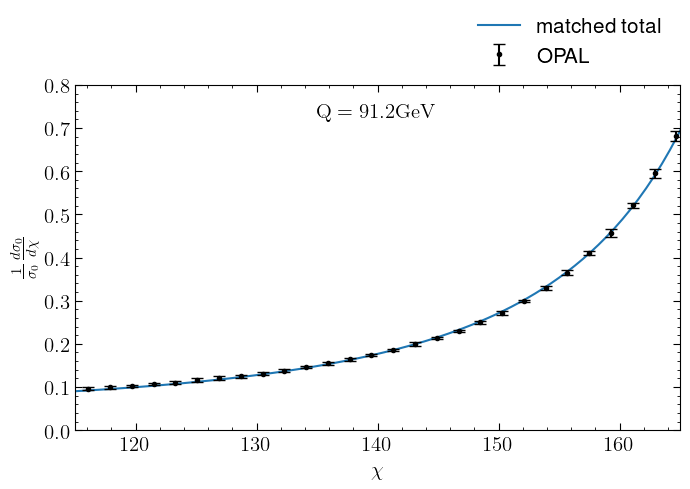

In [57]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched total")
ax1.errorbar(χ_OPAL, EEC_OPAL, yerr=STAT_OPAL, fmt='o',label="OPAL",color="black", capsize=4,markersize=3)

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,0.8)
plt.xlim(115,165)

plt.tight_layout()  
plt.show()

In [47]:
non_singular = []
perturbation = []

χ_OPAL_trans = np.pi/180*χ_OPAL
resum = Main.sigma_fast(Q=91.2, χ_list=χ_OPAL_trans, μ_ini=91.1876, αs_ini=αs, nf=5, order=2, Ω1=Ω1)
for x in χ_OPAL_trans:
    non_singular.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=αs, nf=5, order=2)) 
residual = resum + non_singular - EEC_OPAL

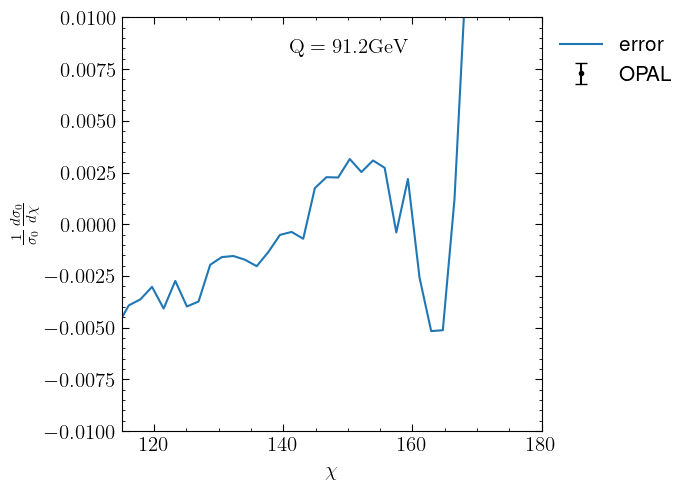

In [58]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.errorbar(χ_OPAL[::2], EEC_OPAL[::2], yerr=STAT_OPAL[::2], fmt='o',label="OPAL",color="black", capsize=4,markersize=3)
ax1.plot(χ_OPAL, residual, label="error")

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(-0.01,0.01)
plt.xlim(115,180)

#plt.xticks([0,30,60,90,120,150,180])
#plt.yticks([0.3,0.6,0.9,1.2,1.5,1.8])

plt.tight_layout()  
plt.show()

In [ ]:
initial_params = [0.118, 2.0]
bounds = [[0.113  , 0.123]
          ,[0.0   , 10.0]]
#          ,[-10.0 , 10.0]
#          ,[-10.0 , 10.0]           
#        ]

progress_callback = ProgressCallback(χ_OPAL, EEC_OPAL, STAT_OPAL)

result = minimize(
    fun=objective,
    x0=initial_params,
    args=(χ_OPAL, EEC_OPAL, STAT_OPAL),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'disp': True},
    #tol = 0.00001,
    callback=progress_callback
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")